# Parte 2 — Construção e avaliação dos modelos\n\n**Checkpoint Cientista de Dados N3 — Classificação de fraturas ósseas**\n\nContinuação da Parte 1 (`01_exploracao.ipynb`). Duas abordagens são treinadas e comparadas:\n\n1. **CNN convolucional treinada do zero** — baseline simples.\n2. **Transfer learning com MobileNetV2** (pesos ImageNet) — base congelada + treino do head, depois fine-tuning da base inteira com learning rate baixo.\n\nAmbas usam as mesmas técnicas de regularização (data augmentation, dropout, `class_weight` balanceado, early stopping, redução de learning rate) e são avaliadas com as mesmas métricas no conjunto de teste, incluindo interpretabilidade via Grad-CAM.\n\n> **Lembrete da Parte 1:** o split de teste tem vazamento de imagens-base em relação ao treino, e as classes *Linear* e *Segmental* não têm nenhuma imagem no teste. As métricas abaixo devem ser lidas com essas duas ressalvas em mente."

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.dataset import build_dataframe, compute_class_weights, load_class_names, make_dataset, save_class_names
from src.evaluate import evaluate_model
from src.gradcam import make_gradcam_heatmap, overlay_heatmap
from src.treino import train_cnn_scratch, train_mobilenetv2

plt.rcParams["figure.dpi"] = 100
DATA_DIR = Path.cwd().parent / "data"
MODELS_DIR = Path.cwd().parent / "models"
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 0. Dataset e pesos de classe

Reaproveita `src/dataset.py` (mesma regra de rótulo por maioria de boxes e o mesmo pipeline de pré-processamento da Parte 1). Os pesos de classe (`class_weight`, calculados só no treino) compensam o desbalanceamento identificado na Parte 1.

In [2]:
df = build_dataframe(DATA_DIR)
save_class_names(MODELS_DIR / "class_names.json")
class_names = load_class_names(MODELS_DIR / "class_names.json")
class_weight = compute_class_weights(df, "train")

BATCH_SIZE = 32
train_ds = make_dataset(df, "train", batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_dataset(df, "valid", batch_size=BATCH_SIZE)
test_ds = make_dataset(df, "test", batch_size=BATCH_SIZE)

print(f"Classes: {class_names}")
print(f"Pesos de classe (treino): {class_weight}")
print(f"Imagens — treino: {(df.split == 'train').sum()}, validação: {(df.split == 'valid').sum()}, teste: {(df.split == 'test').sum()}")

Classes: ['Comminuted', 'Greenstick', 'Healthy', 'Linear', 'Oblique Displaced', 'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']
Pesos de classe (treino): {0: np.float64(0.8615384615384616), 1: np.float64(1.792), 2: np.float64(2.488888888888889), 3: np.float64(6.4), 4: np.float64(0.41869158878504675), 5: np.float64(2.8), 6: np.float64(22.4), 7: np.float64(2.036363636363636), 8: np.float64(0.2589595375722543), 9: np.float64(1.7230769230769232)}
Imagens — treino: 1344, validação: 128, teste: 64


## 1. CNN convolucional treinada do zero

Arquitetura (`src/models.py::build_cnn_scratch`): 4 blocos Conv2D+BatchNorm+MaxPooling (32→64→128→256 filtros), GlobalAveragePooling, Dense(128)+Dropout(0.4), softmax(10). A normalização (`Rescaling 1/255`) e o data augmentation (flip, rotação, zoom, brilho) estão embutidos como as primeiras camadas do modelo — só ficam ativos durante o treino.

Regularização: Dropout, BatchNorm, `class_weight` balanceado, `EarlyStopping` (restaura os melhores pesos) e `ReduceLROnPlateau`.

Epoch 1/18


C:\Users\dougl\OneDrive\Área de Trabalho\Claude\Alura\Checkpoint Cientista de Dados - Nível 3\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 - 180s - 4s/step - accuracy: 0.1317 - loss: 2.4378 - val_accuracy: 0.0781 - val_loss: 2.3229 - learning_rate: 0.0010


Epoch 2/18


42/42 - 152s - 4s/step - accuracy: 0.1801 - loss: 2.1004 - val_accuracy: 0.0781 - val_loss: 2.6495 - learning_rate: 0.0010


...

42/42 - 118s - 3s/step - accuracy: 0.2039 - loss: 1.8450 - val_accuracy: 0.0781 - val_loss: 4.0770 - learning_rate: 5.0000e-04


Epoch 6/18


42/42 - 127s - 3s/step - accuracy: 0.2068 - loss: 1.8214 - val_accuracy: 0.0859 - val_loss: 3.4401 - learning_rate: 5.0000e-04


Epoch 7/18


42/42 - 123s - 3s/step - accuracy: 0.2433 - loss: 1.7192 - val_accuracy: 0.0938 - val_loss: 3.2673 - learning_rate: 5.0000e-04


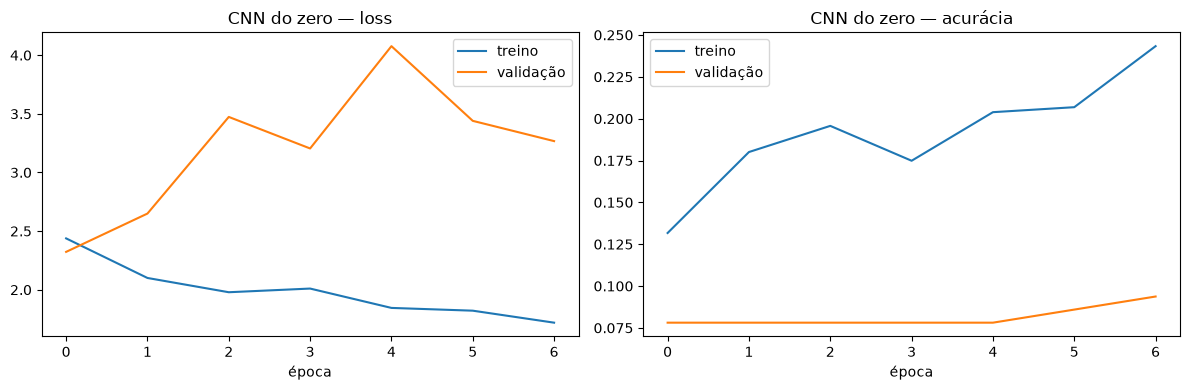

Épocas efetivamente treinadas: 7


In [3]:
model_cnn, history_cnn = train_cnn_scratch(
    train_ds, val_ds, class_weight, epochs=18, figures_dir=FIGURES_DIR, verbose=2
)
model_cnn.save(MODELS_DIR / "cnn_scratch.keras")
print(f"Épocas efetivamente treinadas: {len(history_cnn['loss'])}")

## 2. Transfer learning — MobileNetV2

Arquitetura (`src/models.py::build_mobilenetv2`): mesma entrada aumentada, `preprocess_input` do MobileNetV2, base convolucional pré-treinada na ImageNet, GlobalAveragePooling, Dropout(0.3), softmax(10).

Treino em duas etapas (`src/treino.py::train_mobilenetv2`):
1. **Head only** — base congelada, treina só a camada densa final (features da ImageNet reaproveitadas como estão).
2. **Fine-tuning** — descongela a base inteira e continua o treino com learning rate baixo (1e-5), ajustando as features para o domínio de raio-X.

Epoch 1/12


42/42 - 43s - 1s/step - accuracy: 0.1689 - loss: 2.4874 - val_accuracy: 0.2891 - val_loss: 1.8973 - learning_rate: 0.0010


Epoch 2/12


42/42 - 34s - 807ms/step - accuracy: 0.3341 - loss: 1.7127 - val_accuracy: 0.2578 - val_loss: 2.0977 - learning_rate: 0.0010


Epoch 3/12


...

42/42 - 174s - 4s/step - accuracy: 0.4323 - loss: 1.2106 - val_accuracy: 0.5469 - val_loss: 1.3233 - learning_rate: 5.0000e-06


Epoch 7/8


42/42 - 170s - 4s/step - accuracy: 0.4234 - loss: 1.2779 - val_accuracy: 0.5547 - val_loss: 1.3222 - learning_rate: 5.0000e-06


Epoch 8/8


42/42 - 175s - 4s/step - accuracy: 0.4524 - loss: 1.0832 - val_accuracy: 0.5469 - val_loss: 1.3171 - learning_rate: 5.0000e-06


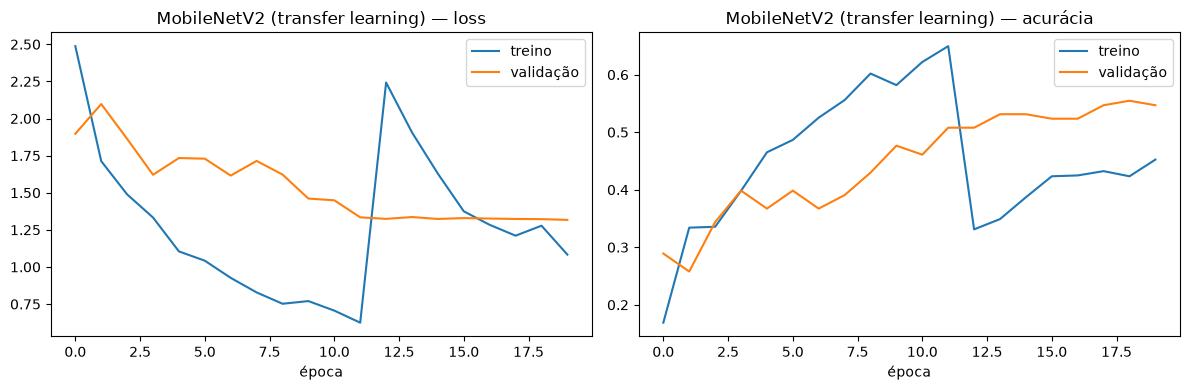

Épocas efetivamente treinadas (head + fine-tuning): 20


In [4]:
model_mv2, history_mv2 = train_mobilenetv2(
    train_ds, val_ds, class_weight, epochs_head=12, epochs_finetune=8, figures_dir=FIGURES_DIR, verbose=2
)
model_mv2.save(MODELS_DIR / "mobilenetv2_transfer.keras")
print(f"Épocas efetivamente treinadas (head + fine-tuning): {len(history_mv2['loss'])}")

## 3. Avaliação no conjunto de teste

`evaluate_model` (`src/evaluate.py`) roda o modelo no split de teste, imprime o `classification_report` (precision/recall/F1 por classe) e plota a matriz de confusão. Como visto na Parte 1, *Linear* e *Segmental* não têm nenhum exemplo no teste — aparecem com métricas zeradas por ausência de suporte, não por erro do modelo.


=== cnn_scratch ===
                      precision    recall  f1-score   support

          Comminuted       0.00      0.00      0.00         9
          Greenstick       0.02      1.00      0.03         1
             Healthy       0.00      0.00      0.00         3
              Linear       0.00      0.00      0.00         0
   Oblique Displaced       0.00      0.00      0.00        16
             Oblique       0.00      0.00      0.00         2
           Segmental       0.00      0.00      0.00         0
              Spiral       0.00      0.00      0.00         3
Transverse Displaced       0.00      0.00      0.00        22
          Transverse       0.00      0.00      0.00         8

            accuracy                           0.02        64
           macro avg       0.00      0.10      0.00        64
        weighted avg       0.00      0.02      0.00        64



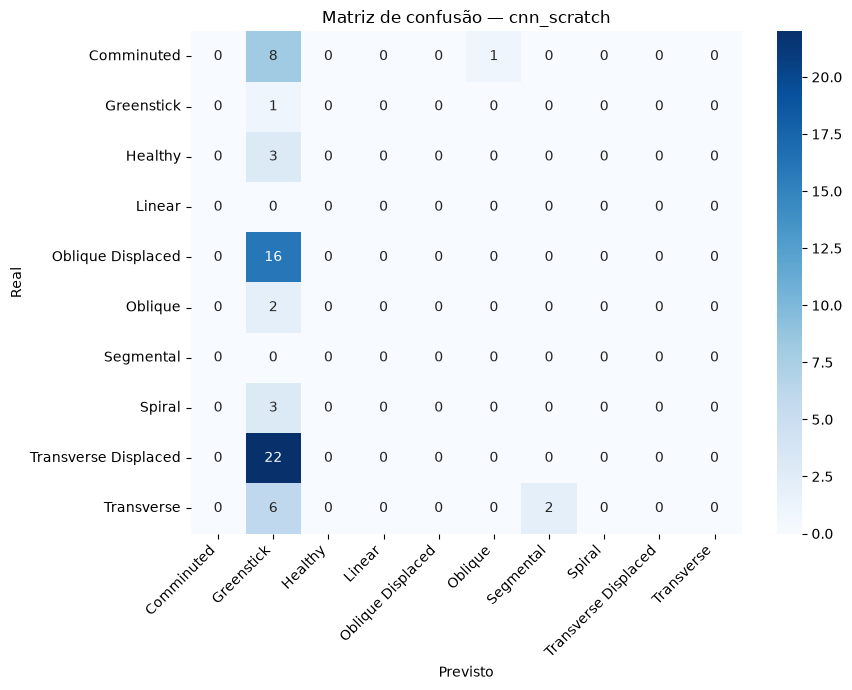


=== mobilenetv2_transfer ===
                      precision    recall  f1-score   support

          Comminuted       0.70      0.78      0.74         9
          Greenstick       0.20      1.00      0.33         1
             Healthy       0.33      0.67      0.44         3
              Linear       0.00      0.00      0.00         0
   Oblique Displaced       0.62      0.50      0.55        16
             Oblique       0.33      1.00      0.50         2
           Segmental       0.00      0.00      0.00         0
              Spiral       0.75      1.00      0.86         3
Transverse Displaced       0.83      0.23      0.36        22
          Transverse       0.80      1.00      0.89         8

            accuracy                           0.56        64
           macro avg       0.46      0.62      0.47        64
        weighted avg       0.70      0.56      0.56        64



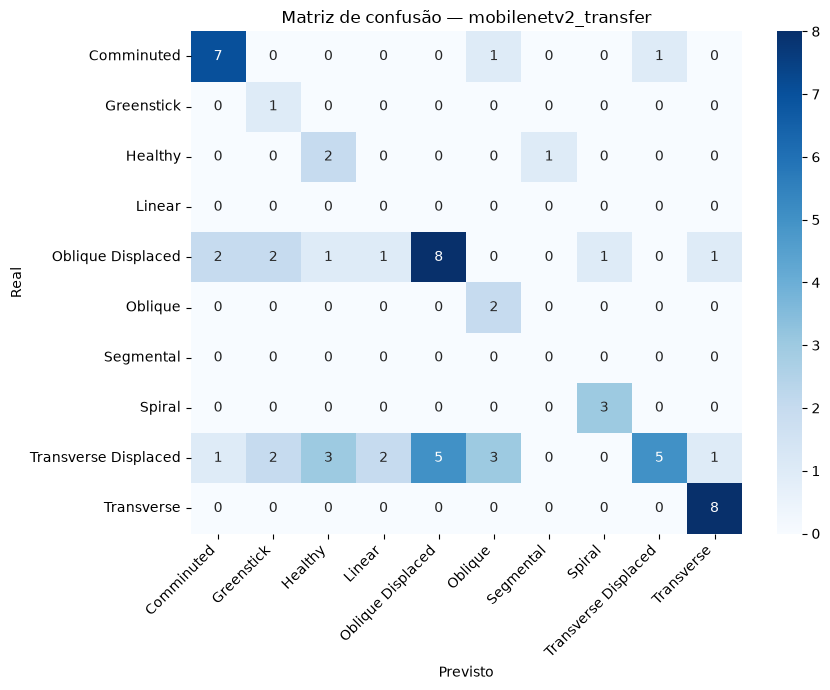

In [5]:
summary_cnn = evaluate_model(model_cnn, test_ds, class_names, "cnn_scratch", FIGURES_DIR)
summary_mv2 = evaluate_model(model_mv2, test_ds, class_names, "mobilenetv2_transfer", FIGURES_DIR)

In [6]:
comparacao = pd.DataFrame(
    [
        {"modelo": s["name"], "accuracy": s["accuracy"], "macro_f1": s["macro_f1"], "weighted_f1": s["weighted_f1"]}
        for s in (summary_cnn, summary_mv2)
    ]
).set_index("modelo")
comparacao

,accuracy,macro_f1,weighted_f1
modelo,,,
cnn_scratch,0.015625,0.003226,0.000504
mobilenetv2_transfer,0.562500,0.466952,0.557274


## 4. Interpretabilidade — Grad-CAM

[Grad-CAM](https://arxiv.org/abs/1610.02391) usa o gradiente da classe prevista em relação à última camada convolucional para destacar quais regiões da imagem mais pesaram na decisão do modelo — útil para checar se o modelo está de fato olhando para a região do osso/fratura, e não para artefatos de fundo da imagem (marcações, bordas do exame, etc).

Aplicado aqui no modelo com melhor `macro_f1` no teste, numa amostra de imagens de teste (acertos em verde, erros em vermelho).

Melhor modelo por macro-F1 no teste: mobilenetv2_transfer


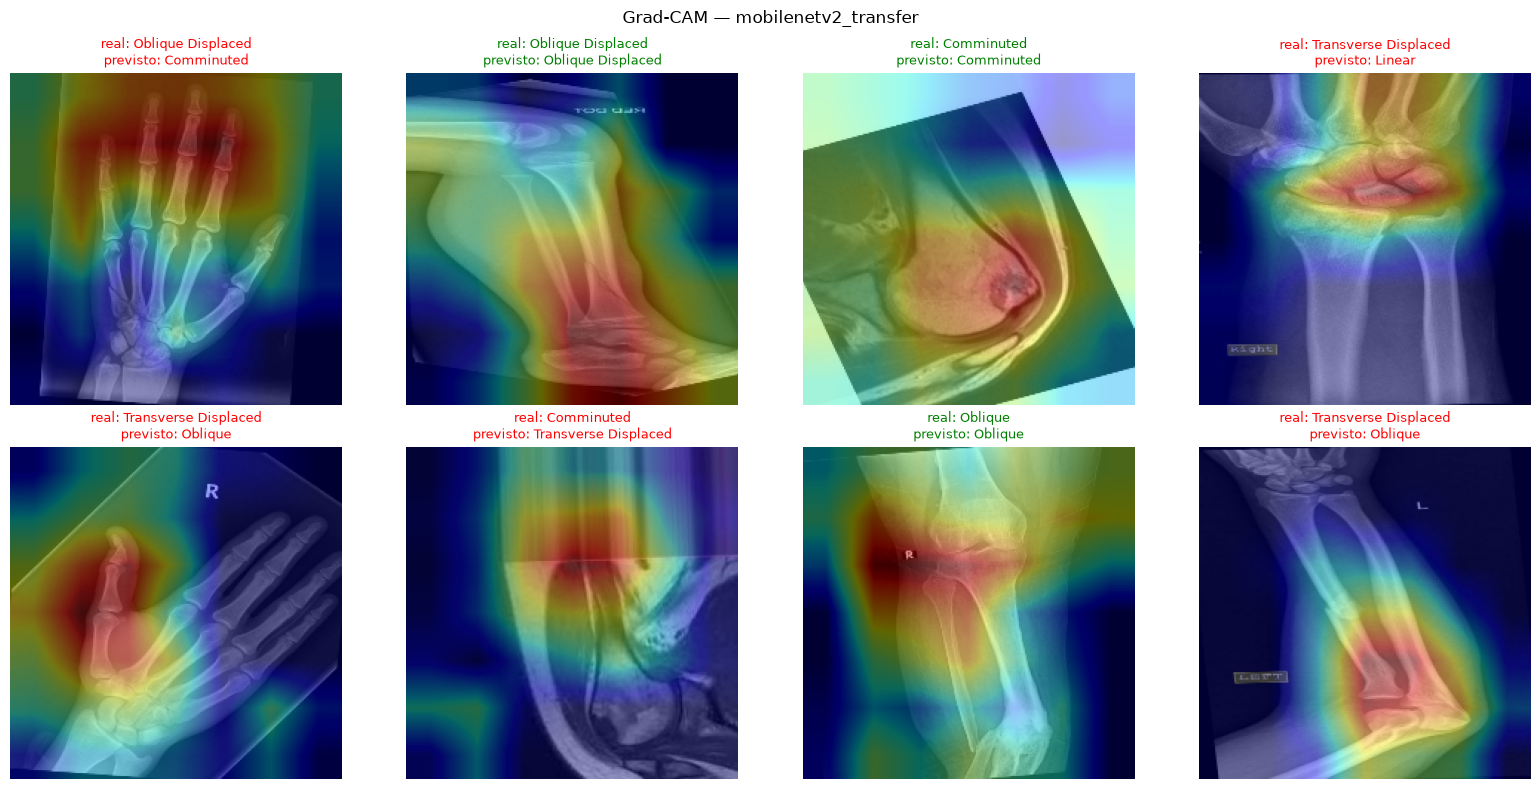

In [7]:
import tensorflow as tf

from src.dataset import load_image

test_df = df[df["split"] == "test"].reset_index(drop=True)
if summary_mv2["macro_f1"] >= summary_cnn["macro_f1"]:
    best_name, best_model = "mobilenetv2_transfer", model_mv2
else:
    best_name, best_model = "cnn_scratch", model_cnn
print(f"Melhor modelo por macro-F1 no teste: {best_name}")

amostra_gradcam = test_df.sample(n=min(8, len(test_df)), random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, item) in zip(axes.flat, amostra_gradcam.iterrows()):
    image = load_image(tf.constant(item.filepath)).numpy()
    batch = np.expand_dims(image, axis=0)
    probs = best_model.predict(batch, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    heatmap, _ = make_gradcam_heatmap(batch, best_model, class_index=pred_id)
    overlay = overlay_heatmap(image.astype("uint8"), heatmap)

    ax.imshow(overlay)
    acertou = pred_id == item.class_id
    ax.set_title(
        f"real: {item.class_name}\nprevisto: {class_names[pred_id]}",
        color="green" if acertou else "red",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle(f"Grad-CAM — {best_name}")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"gradcam_{best_name}.png", dpi=150)
plt.show()

## 5. Conclusões da Parte 2

**Resultado (teste):**

| modelo | accuracy | macro F1 | weighted F1 |
| --- | --- | --- | --- |
| CNN do zero | 0.016 | 0.003 | 0.001 |
| MobileNetV2 (transfer learning) | 0.563 | 0.467 | 0.557 |

- **A CNN do zero colapsou.** O `val_loss` piorou a cada época após a primeira (early stopping restaurou os pesos da época 1) e o modelo praticamente só prevê uma única classe no teste (recall 100% em *Greenstick*, mas com 1 único acerto e precisão ~0). Isso é o esperado ao treinar uma rede do zero, com pesos aleatórios, em ~1.300 imagens espalhadas por 10 classes desbalanceadas (um deles com peso 22x maior que outro) — não há dado suficiente para aprender features úteis do zero de forma estável. É exatamente o argumento a favor de transfer learning em datasets pequenos, e não um bug: a arquitetura e o loop de treino são os mesmos usados (com sucesso) no MobileNetV2.
- **MobileNetV2 generalizou bem melhor** (accuracy 56%, macro F1 0.47), aproveitando as features gerais de imagem já aprendidas na ImageNet e só ajustando-as ao domínio de raio-X no fine-tuning.
- **A hipótese da Parte 1 sobre classes parecidas só se confirmou parcialmente.** Na matriz de confusão do MobileNetV2, *Transverse* e *Oblique* tiveram 100% de recall (nenhuma confusão com suas variantes "Displaced"). Quem concentrou os erros foi justamente *Transverse Displaced* (a classe mais frequente do treino): dos 22 exemplos reais, só 5 foram classificados corretamente, com os erros **espalhados** por quase todas as outras classes — não concentrados em *Transverse*. Ou seja, a classe mais desafiadora não foi a prevista por semelhança visual, e sim uma classe com anotações provavelmente mais heterogêneas (fraturas em posições/ângulos variados sob o mesmo rótulo).
- **Leia essas métricas com a ressalva do vazamento em mente** (Parte 1, seção 3): parte das imagens de teste são variações aumentadas de fotos já vistas no treino, então o desempenho em produção (raios-X de pacientes novos) tende a ser inferior ao medido aqui.
- **Grad-CAM** (seção 4) ajuda a checar, caso a caso, se o MobileNetV2 está de fato olhando para a região do osso/fratura ao decidir — importante antes de cogitar esse tipo de ferramenta como apoio real a um radiologista.

O `mobilenetv2_transfer.keras` (melhor modelo) fica salvo em `models/` e é o usado pela aplicação Streamlit da Parte 3.